In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "styles.csv",
    on_bad_lines='skip'
)

In [3]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
df.columns

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')

In [5]:
pd.set_option('display.max_rows', None)

df['articleType'].value_counts()

articleType
Tshirts                      7067
Shirts                       3217
Casual Shoes                 2845
Watches                      2542
Sports Shoes                 2036
Kurtas                       1844
Tops                         1762
Handbags                     1759
Heels                        1323
Sunglasses                   1073
Wallets                       936
Flip Flops                    914
Sandals                       897
Briefs                        849
Belts                         813
Backpacks                     724
Socks                         686
Formal Shoes                  637
Perfume and Body Mist         613
Jeans                         609
Shorts                        547
Trousers                      530
Flats                         500
Bra                           477
Dresses                       464
Sarees                        427
Earrings                      416
Deodorant                     347
Nail Polish                   329
Li

In [6]:
df['articleType'].nunique()

143

In [12]:
clases = [
    "Tshirts",
    "Shirts",
    "Casual Shoes",
    "Sports Shoes",
    "Tops",
    "Handbags",
    "Heels",
    "Sandals",
    "Shorts",
    "Trousers",
    "Jeans"
]

In [8]:
df_filtrado = df[
    df['articleType'].isin(clases)
]

In [9]:
df_filtrado['articleType'].value_counts()

articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Sports Shoes    2036
Tops            1762
Handbags        1759
Heels           1323
Sandals          897
Jeans            609
Shorts           547
Trousers         530
Name: count, dtype: int64

In [10]:
df_filtrado.isnull().sum()

id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             6
season                21
year                   1
usage                  5
productDisplayName     0
dtype: int64

In [11]:
df_filtrado = df_filtrado.dropna()

In [12]:
df_filtrado['articleType'].isnull().sum()

np.int64(0)

In [13]:
df_filtrado['id'].isnull().sum()

np.int64(0)

In [14]:
df_filtrado['ruta'] = (
    "images/" +
    df_filtrado['id'].astype(str) +
    ".jpg"
)

In [15]:
df_filtrado[['ruta', 'articleType']].head()

,ruta,articleType
0,images/15970.jpg,Shirts
1,images/39386.jpg,Jeans
4,images/53759.jpg,Tshirts
5,images/1855.jpg,Tshirts
6,images/30805.jpg,Shirts


In [16]:
#verificar imágenes faltantes
import os

df_filtrado = df_filtrado[
    df_filtrado['ruta'].apply(os.path.exists)
] 

In [17]:
encoder = LabelEncoder()

In [18]:
df_filtrado['label'] = encoder.fit_transform(
    df_filtrado['articleType']
)

In [19]:
train_df, test_df = train_test_split(
    df_filtrado,
    test_size=0.2,
    random_state=42,
    stratify=df_filtrado['label']
)

In [20]:
def cargar_imagen(ruta, label):

    imagen = tf.io.read_file(ruta)

    imagen = tf.image.decode_jpeg(
        imagen,
        channels=3
    )

    imagen = tf.image.resize(
        imagen,
        (224, 224)
    )

    imagen = preprocess_input(imagen)

    return imagen, label

In [21]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df['ruta'].values,
        train_df['label'].values
    )
)

In [22]:
train_dataset = train_dataset.map(cargar_imagen)

In [23]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df['ruta'].values,
        test_df['label'].values
    )
)

test_dataset = test_dataset.map(cargar_imagen)

In [24]:
BATCH_SIZE = 32

In [25]:
train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [26]:
test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [27]:
def cargar_imagen(ruta, label):

    # Leer archivo
    imagen = tf.io.read_file(ruta)

    # Decodificar JPG
    imagen = tf.image.decode_jpeg(
        imagen,
        channels=3
    )

    # Resize para MobileNet
    imagen = tf.image.resize(
        imagen,
        (224, 224)
    )

    # Preprocessing específico
    imagen = preprocess_input(imagen)

    return imagen, label

In [28]:
#importar mobilenet
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

In [29]:
base_model.trainable = False #que deje de aprender

In [30]:
#construir el mododelo
modelo = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(
        len(clases),
        activation='softmax'
    )
])

In [31]:
modelo.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [32]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,371 (9.24 MB)

 Trainable params: 165,387 (646.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
#entrenamiento del modelo
historial = modelo.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=5

)

Epoch 1/5
564/564 ━━━━━━━━━━━━━━━━━━━━ 221s 386ms/step - accuracy: 0.8257 - loss: 0.4653 - val_accuracy: 0.8892 - val_loss: 0.2778
Epoch 2/5
564/564 ━━━━━━━━━━━━━━━━━━━━ 221s 391ms/step - accuracy: 0.8801 - loss: 0.3052 - val_accuracy: 0.8963 - val_loss: 0.2588
Epoch 3/5
564/564 ━━━━━━━━━━━━━━━━━━━━ 223s 394ms/step - accuracy: 0.8985 - loss: 0.2613 - val_accuracy: 0.8974 - val_loss: 0.2624
Epoch 4/5
564/564 ━━━━━━━━━━━━━━━━━━━━ 216s 382ms/step - accuracy: 0.9071 - loss: 0.2406 - val_accuracy: 0.9003 - val_loss: 0.2520
Epoch 5/5
564/564 ━━━━━━━━━━━━━━━━━━━━ 217s 384ms/step - accuracy: 0.9123 - loss: 0.2212 - val_accuracy: 0.8987 - val_loss: 0.2595


In [34]:
modelo.save("fashion_mobilenet.keras")

In [35]:
modelo.evaluate(test_dataset)

141/141 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step - accuracy: 0.8987 - loss: 0.2595


[0.2594980299472809, 0.898714542388916]

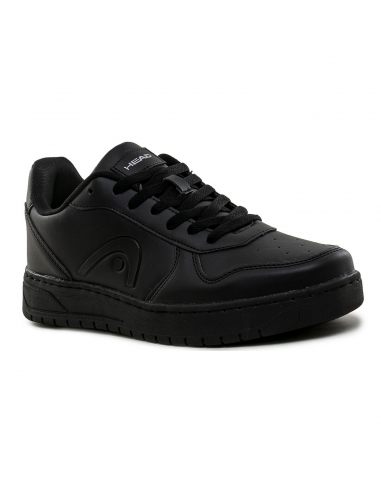

In [3]:
ruta = "zapatisha.jpg"

imagen = Image.open(ruta)

imagen

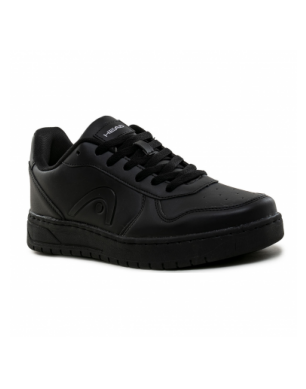

In [4]:
plt.imshow(imagen)
plt.axis("off")
plt.show()

In [5]:
imagen = imagen.convert("RGB")

imagen = imagen.resize((224,224))

imagen_array = np.array(imagen)

imagen_array = preprocess_input(imagen_array)

imagen_array = np.expand_dims(
    imagen_array,
    axis=0
)

In [9]:
prediccion = modelo.predict(imagen_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [13]:
indice = np.argmax(prediccion)

clase = encoder.classes_[indice]

confianza = prediccion[0][indice]

NameError: name 'encoder' is not defined

In [53]:
print("Clase:", clase)

print("Confianza:", confianza)

Clase: Casual Shoes
Confianza: 0.7873003


In [54]:
import joblib

# Guardar el encoder en un archivo .pkl
joblib.dump(encoder, "encoder.pkl")


['encoder.pkl']